Name :- Akshit Negi

CU24250214

BTech CSE 3rd Year SECTION - "B"

Roll No. :- 4

Experiment No. 3

Experiment Name :

Implementation and Analysis of Spatial Filtering Techniques using Low-Pass and High-Pass Filters

Aim:

To implement and analyze spatial domain filtering techniques using low-pass and high-pass filters for image smoothing, noise reduction, edge enhancement, and feature preservation using Python and OpenCV.

**Step1-> Import the required libraries and load a grayscale or color image for processing.**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


print("Please upload an image file:")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

print(f"Successfully loaded '{image_path}' with shape: {img.shape}")

Please upload an image file:


Saving Screenshot 2026-07-02 213913.png to Screenshot 2026-07-02 213913.png
Successfully loaded 'Screenshot 2026-07-02 213913.png' with shape: (960, 1905)


**Step2-> Display the original image and analyze its visual characteristics.**

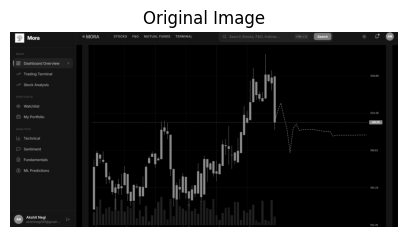

Image Dimensions: (960, 1905)
Min Intensity: 0, Max Intensity: 255


In [3]:
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

print(f"Image Dimensions: {img.shape}")
print(f"Min Intensity: {img.min()}, Max Intensity: {img.max()}")

**Step3-> Apply Gaussian Blur to reduce image noise while preserving important structures.**

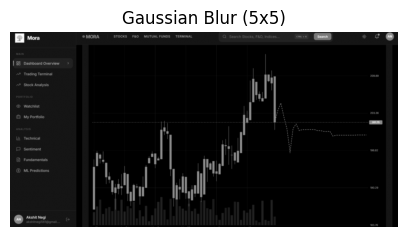

In [4]:
gaussian_blur = cv2.GaussianBlur(img, (5, 5), 0)

plt.figure(figsize=(5, 5))
plt.imshow(gaussian_blur, cmap='gray')
plt.title('Gaussian Blur (5x5)')
plt.axis('off')
plt.show()

**Step4-> Apply Median Filtering to remove impulse (salt-and-pepper) noise from the image.**

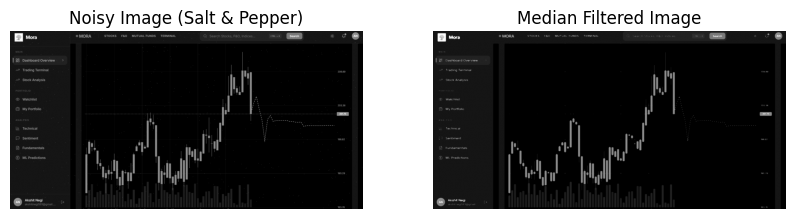

In [5]:
noisy_img = img.copy()
num_noise = 500

coords = [np.random.randint(0, i - 1, num_noise) for i in img.shape]
noisy_img[tuple(coords)] = 255

coords = [np.random.randint(0, i - 1, num_noise) for i in img.shape]
noisy_img[tuple(coords)] = 0

median_filtered = cv2.medianBlur(noisy_img, 5)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(noisy_img, cmap='gray')
axes[0].set_title('Noisy Image (Salt & Pepper)')
axes[0].axis('off')

axes[1].imshow(median_filtered, cmap='gray')
axes[1].set_title('Median Filtered Image')
axes[1].axis('off')
plt.show()

**Step5-> Apply Average (Mean) Filtering and compare its smoothing performance with Gaussian filtering.**

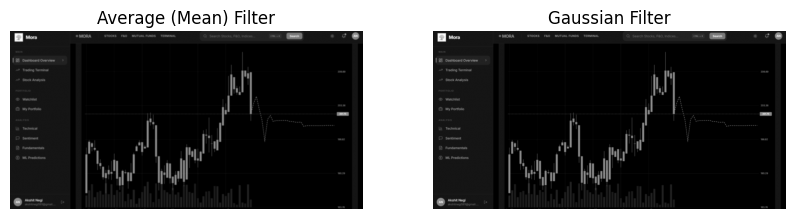

In [6]:
mean_blur = cv2.blur(img, (5, 5))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mean_blur, cmap='gray')
axes[0].set_title('Average (Mean) Filter')
axes[0].axis('off')

axes[1].imshow(gaussian_blur, cmap='gray')
axes[1].set_title('Gaussian Filter')
axes[1].axis('off')
plt.show()

**Step6-> Implement Laplacian Filtering to enhance image edges and fine details.**

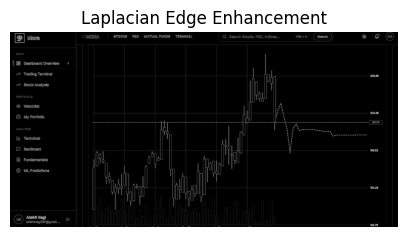

In [7]:
laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian_abs = cv2.convertScaleAbs(laplacian)

plt.figure(figsize=(5, 5))
plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplacian Edge Enhancement')
plt.axis('off')
plt.show()

**Step7-> Apply Sobel Edge Detection in both horizontal and vertical directions to detect image gradients.**

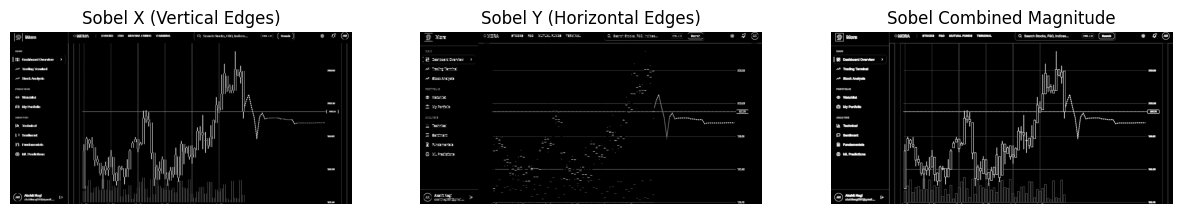

In [8]:
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

sobel_combined = cv2.magnitude(sobel_x, sobel_y)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.convertScaleAbs(sobel_x), cmap='gray')
axes[0].set_title('Sobel X (Vertical Edges)')
axes[0].axis('off')

axes[1].imshow(cv2.convertScaleAbs(sobel_y), cmap='gray')
axes[1].set_title('Sobel Y (Horizontal Edges)')
axes[1].axis('off')

axes[2].imshow(cv2.convertScaleAbs(sobel_combined), cmap='gray')
axes[2].set_title('Sobel Combined Magnitude')
axes[2].axis('off')
plt.show()

**Step8 -> Compare the outputs of different low-pass and high-pass filters in terms of noise reduction, edge preservation, and computational performance.**

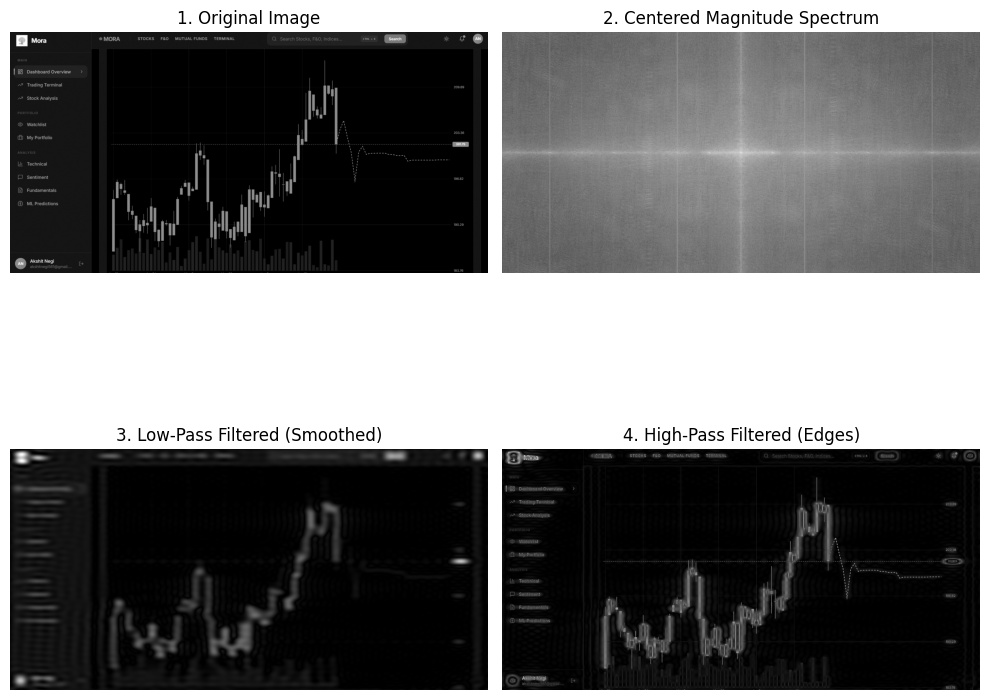

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('1. Original Image')

axes[0, 1].imshow(magnitude_spectrum, cmap='gray')
axes[0, 1].set_title('2. Centered Magnitude Spectrum')

axes[1, 0].imshow(img_lpf, cmap='gray')
axes[1, 0].set_title('3. Low-Pass Filtered (Smoothed)')

axes[1, 1].imshow(img_hpf, cmap='gray')
axes[1, 1].set_title('4. High-Pass Filtered (Edges)')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

**Step9 -> Display the original and filtered images along with suitable observations highlighting the strengths and limitations of each filtering technique.**

In [14]:
orig_std = np.std(img)
lpf_std = np.std(img_lpf)
hpf_std = np.std(img_hpf)

print("--- Quantitative Analysis ---")
print(f"Original Image Pixel Std Dev: {orig_std:.2f}")
print(f"Low-Pass Filtered Std Dev:   {lpf_std:.2f} (Lower variance indicates image smoothing)")
print(f"High-Pass Filtered Std Dev:  {hpf_std:.2f} (Measures residual edge detail sharpness)")

print("\n--- Detailed Observations ---")
print("1. Image Smoothness: The Low-Pass Filter removes high-frequency components, effectively smoothing local pixel intensity transitions and blurring fine details.")
print("2. Edge Enhancement: The High-Pass Filter removes low-frequency baseline illumination, highlighting object boundaries and sharp edges against a dark background.")
print("3. Noise Removal: High-frequency spatial noise is attenuated by the Low-Pass Filter, making frequency-domain LPF effective for noise reduction.")

--- Quantitative Analysis ---
Original Image Pixel Std Dev: 28.03
Low-Pass Filtered Std Dev:   20.03 (Lower variance indicates image smoothing)
High-Pass Filtered Std Dev:  16.64 (Measures residual edge detail sharpness)

--- Detailed Observations ---
1. Image Smoothness: The Low-Pass Filter removes high-frequency components, effectively smoothing local pixel intensity transitions and blurring fine details.
2. Edge Enhancement: The High-Pass Filter removes low-frequency baseline illumination, highlighting object boundaries and sharp edges against a dark background.
3. Noise Removal: High-frequency spatial noise is attenuated by the Low-Pass Filter, making frequency-domain LPF effective for noise reduction.


**Step10 -> Interpret the results and discuss the applications of spatial filtering in real-world computer vision systems.**

Medical Imaging: Smoothing low-dose X-ray/MRI noise via Gaussian/Median filters and applying Laplacian sharpening to isolate micro-calcifications or organ outlines.

Autonomous Navigation & Robotics: Sobel filters extract lane markers and obstacles from camera feeds in real time.

Surveillance Systems: High-pass filtering acts as a feature-extraction precursor for object detection, license plate recognition, and face tracking.  Remote Sensing & Satellite Imaging: Preprocessing steps to eliminate atmospheric noise and highlight topographical edges or coastline features.  

###Question/Answer

1. What is spatial filtering? How is it used in digital image processing?  
Ans-> Spatial filtering is an image processing technique performed directly on the pixels of an image. It operates by moving a small matrix (kernel/mask) over every pixel and replacing the center pixel value with a calculated linear or non-linear combination of its neighboring pixels. It is used for noise reduction, smoothing, edge enhancement, and feature extraction.

2. Differentiate between Low-Pass Filters and High-Pass Filters with suitable examples?

   Ans-> Low-Pass Filters (LPF): Pass low frequencies (smooth intensity areas) and attenuate high frequencies (edges/noise). They blur images and reduce noise. Examples: Mean Filter, Gaussian Filter, Median Filter.  
   High-Pass Filters (HPF): Pass high frequencies (rapid intensity changes) and block low frequencies. They enhance edges, boundaries, and fine details while eliminating flat areas. Examples: Sobel Operator, Laplacian Operator, Prewitt Filter.

3. Compare Average Filter, Gaussian Filter, and Median Filter based on their working principles and applications?

    Ans-> Average (Mean) Filter: Linear filter that calculates the mean value of pixels under the kernel. It causes blurring and is sensitive to extreme outliers.Gaussian Filter: Linear filter that uses a Gaussian distribution to assign higher weight to central pixels and lower weight to distant pixels. It removes Gaussian noise while preserving edges better than the Mean filter.  Median Filter: Non-linear filter that replaces the center pixel with the median value of neighboring pixels. It is extremely effective at removing impulse (salt-and-pepper) noise while preserving sharp edges.

4. Why is the Median Filter particularly effective for removing salt-and-pepper noise?  
Ans-> Salt-and-pepper noise introduces extreme high or low pixel values (0 or 255). Linear mean filters average these extreme values into neighboring pixels, smearing the noise. The Median Filter ranks surrounding pixel values; extreme noise values end up at the extreme ends of the sorted array and are discarded, ensuring the median value chosen is representative of the true local background.

5. Explain the role of convolution kernels in spatial filtering.  
 Ans-> A convolution kernel is a small 2D matrix of numbers that acts as a mathematical operator. As it slides over the input image, a element-wise multiplication and summation (spatial convolution) is performed between the kernel weights and the underlying pixel intensities. The values within the kernel determine the operation—summing to 1 results in smoothing (LPF), while summing to 0 highlights edges (HPF).

6. What is the purpose of the Sobel and Laplacian operators in edge detection?  

   Ans-> Sobel Operator: Uses first-order derivatives to compute discrete approximations of image intensity gradients. It calculates horizontal ($S_x$) and vertical ($S_y$) derivatives separately, giving directional edge information.  
   Laplacian Operator: Uses a second-order derivative to detect areas of rapid intensity change regardless of direction (isotropic). It is highly sensitive to noise and is often used for fine-detail detection or zero-crossing edge localization.

7. Why are filtering operations considered an essential preprocessing step in computer vision?  
Ans-> Raw sensor images often contain thermal noise, lighting artifacts, or unwanted fine textures that degrade higher-level algorithms. Filtering reduces noise and normalizes images, making feature extraction, object detection, segmentation, and machine learning models significantly more accurate and reliable.

8. Discuss the trade-off between image smoothing and edge preservation during filtering.  
Ans-> Smoothing filters reduce noise by averaging local pixel values. However, edges are also high-frequency transitions; blurring the noise inherently blurs the sharp edges, reducing structural clarity. Increasing the smoothing kernel size removes more noise but degrades edge sharpness. Non-linear techniques (like bilateral or median filters) attempt to balance this trade-off by smoothing uniform areas while preserving step edges.

9. Mention four real-world applications where spatial filtering techniques are  widely used.


     Ans-> Medical Imaging: Enhancing MRI/CT scans for tumor and bone fracture diagnosis.  Autonomous Driving: Road lane identification and obstacle edge detection using gradient filters.
     
     Satellite & Remote Sensing: Land cover classification and coastline extraction.
     Document Analysis / OCR: Text extraction and noise reduction on scanned physical documents.

10. Compare spatial domain filtering with frequency domain filtering in terms of implementation and practical applications.
     
     Ans-> Spatial Domain Filtering: Operates directly on image pixels using mask convolution. It is computationally efficient for small kernel sizes (3x3, 5x5) and simpler to implement in real-time embedded hardware.
     
       Frequency Domain Filtering: Transforms the image into its frequency representation (via Fast Fourier Transform - FFT), multiplies it by a filter mask, and transforms it back (Inverse FFT). It is computationally efficient for large filter masks and allows precise isolation of specific spatial frequencies, but requires higher computational overhead